--- Our Clean Customer Dataset View ---
   CustomerID  Age  Annual_Income_k$  Spending_Score
0           1   19                15              39
1           2   21                15              81
2           3   20                16               6
3           4   23                16              77
4           5   31                17              40 

--- Data with Assigned Groups/Clusters ---
   CustomerID  Annual_Income_k$  Spending_Score  Cluster_Labels
0           1                15              39               2
1           2                15              81               0
2           3                16               6               1
3           4                16              77               0
4           5                17              40               2 



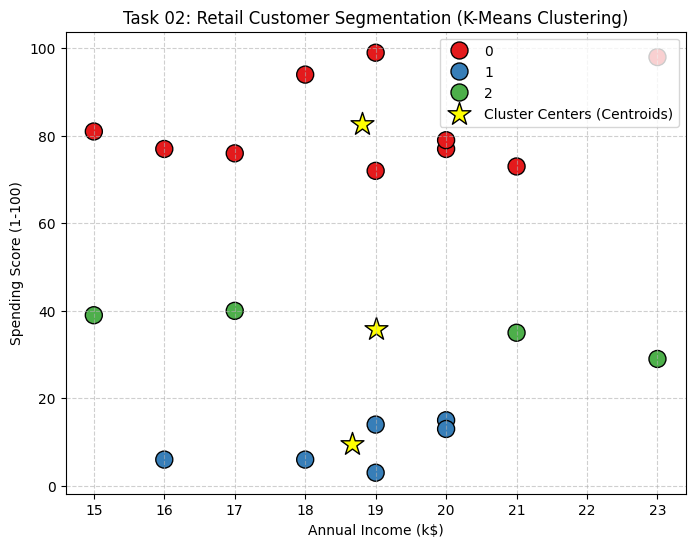

In [1]:
# ==========================================
# TASK 02: K-Means Customer Segmentation
# Repository Naming Format: SCT_ML_2
# ==========================================

# 1. Import the necessary tools (libraries)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 2. Create a clean, representative dataset of retail store customers
# It contains: Customer ID, Age, Annual Income (in thousands), and Spending Score (1 to 100)
np.random.seed(42)
data = {
    'CustomerID': range(1, 21),
    'Age': [19, 21, 20, 23, 31, 22, 35, 23, 64, 30, 67, 35, 58, 24, 37, 22, 35, 20, 52, 35],
    'Annual_Income_k$': [15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 21, 21, 23, 23],
    'Spending_Score': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72, 14, 99, 15, 77, 13, 79, 35, 73, 29, 98]
}

df = pd.DataFrame(data)
print("--- Our Clean Customer Dataset View ---")
print(df.head(), "\n")

# 3. Select the features we want to use for grouping (Income vs Spending Score)
X = df[['Annual_Income_k$', 'Spending_Score']]

# 4. Initialize and Run the K-Means Clustering Algorithm
# We will sort our shoppers into 3 distinct behavioral clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['Cluster_Labels'] = kmeans.fit_predict(X)

print("--- Data with Assigned Groups/Clusters ---")
print(df[['CustomerID', 'Annual_Income_k$', 'Spending_Score', 'Cluster_Labels']].head(), "\n")

# 5. Create a beautiful scatter plot to visualize our customer groups
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual_Income_k$',
    y='Spending_Score',
    hue='Cluster_Labels',
    palette='Set1',
    data=df,
    s=150,
    edgecolor='black'
)

# Plot the center point (centroid) of each cluster
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    marker='*',
    label='Cluster Centers (Centroids)',
    edgecolor='black'
)

plt.title('Task 02: Retail Customer Segmentation (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()